In [1]:
import os
import sys

import numpy as np
import seaborn as sns
import pandas as pd

from matplotlib import pyplot as plt


In [2]:
import sys

sys.path.append("../utils")

import data_io

# setup

In [3]:
cm = 1/2.54  # centimeters in inches
plt.style.use('paper.mplstyle')

In [4]:
order =[ 't1','GluMI','t2', 
        't3a', 't3b',  't4', 't5i', 't5o', 't5t', 'XBC',
        't6', 't7', 't8', 't9','RBC']

In [5]:
cell_type_colors = {'t1': '#da3b3c',
 'GluMI': '#1b75ab',
 't2': '#ffcad4',
 't3a': '#8d86b8',
 't3b': '#f0a54c',
 't4': '#6ca46c',
 't5o': '#0c7c5a',
 't5t': '#e0b0c8',
 't5i': '#487bb9',
 'XBC': '#e5603a',
 't7': '#ecc56f',
 't6': '#137983',
 't8': '#c195bc',
 't9': '#ef8538',
 'RBC': '#cacc7f'} 

In [6]:
GROUPS = {
    'OFF CBCs': ['t1', 'GluMI', 't2', 't3a', 't3b', 't4'],
    'ON CBCs':  ['t5i', 't5o', 't5t', 'XBC', 't6', 't7', 't8', 't9']
}

# load data

In [7]:
config = data_io.get_data_config()
version = config.get("version_rb", None)
file_path = data_io.get_file_path(config,
                                  version = "version_rb",
                                  file_prefix = "file_prefix_rb")

In [8]:
assert os.path.isfile(file_path), file_path

In [9]:
RibbonCellFinal = pd.read_parquet(file_path)

In [10]:
RibbonCellFinal

,rb_centroid_x_warped,rb_centroid_y_warped,rb_centroid_z_warped,cell,cell_type,count,size
0,223.828,909.822,-6.95133,720575940548196547,t6,113.0,0.005413
1,224.005,905.576,-7.17835,720575940548217027,RBC,74.0,0.006444
2,224.112,901.876,-6.20684,720575940548217027,RBC,74.0,0.006444
3,223.922,910.114,-7.58732,720575940548196547,t6,113.0,0.005413
4,224.085,905.021,-4.63896,720575940548196547,t6,113.0,0.005413
...,...,...,...,...,...,...,...
6672075,223.668,904.070,-4.58329,720575940548196547,t6,113.0,0.005413
6672076,223.719,902.051,-5.25367,720575940548217027,RBC,74.0,0.006444
6672077,223.814,904.606,-7.43649,720575940548217027,RBC,74.0,0.006444
6672079,223.780,905.075,-5.23875,720575940548196547,t6,113.0,0.005413


# figure

In [11]:
fig_dir = f'../figures/connectivity/v{version}'
os.makedirs(fig_dir, exist_ok=True)

## panel G: plot denisity across z

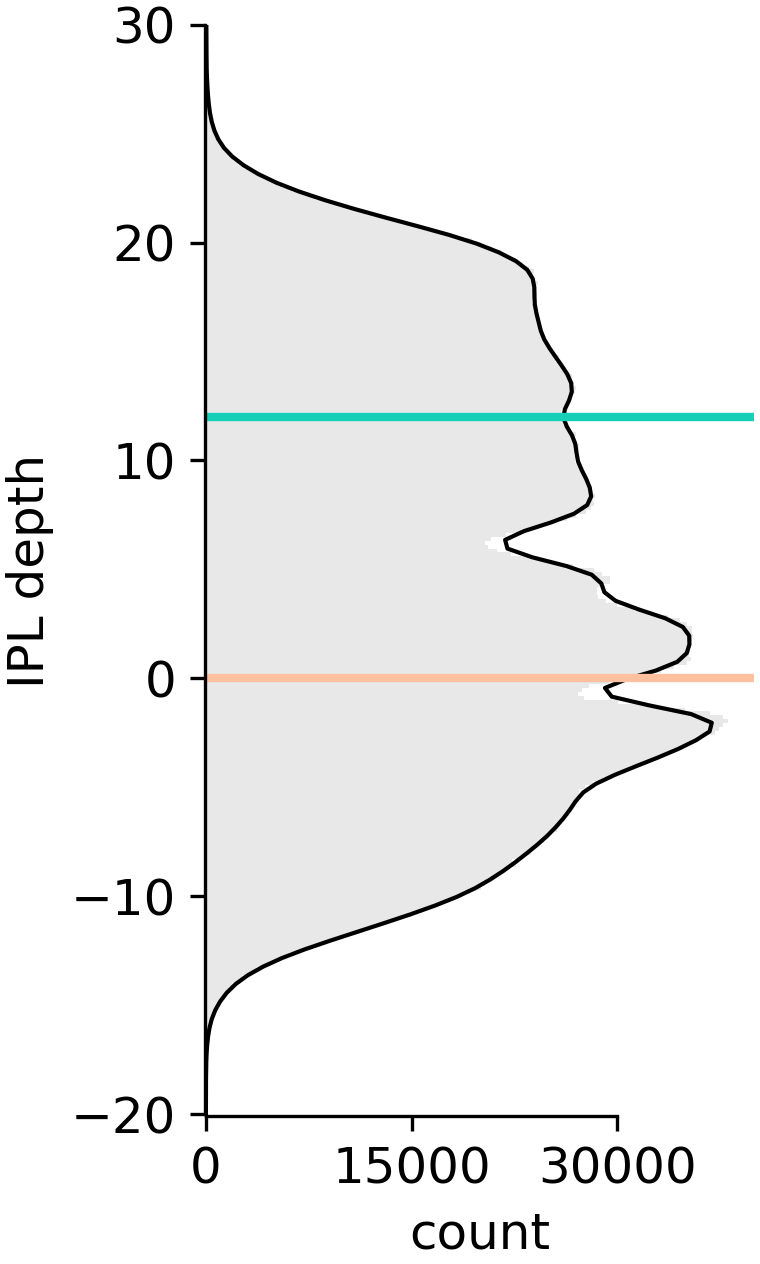

In [12]:
on_sac_pos = 0
off_sac_pos = 12

fig = plt.figure(figsize = (6*cm,12*cm))

gs = fig.add_gridspec(1,1, width_ratios=[1])

ax = fig.add_subplot(gs[0,0])
ax.set_ylim(-20.1,30)
ax.set_xlim(-50,40000)


hist = sns.histplot(RibbonCellFinal,  y = 'rb_centroid_z_warped', kde = True, 
                    common_norm = True, edgecolor = None,
                    color = 'lightgrey',  line_kws={'color': 'k'})

ax.lines[0].set_color('k')
plt.axhline(on_sac_pos, ls = "-",linewidth = 2, c= '#FFC09F')
plt.axhline(off_sac_pos, ls = "-",linewidth = 2, c= '#17CFB9')

plt.ylabel('IPL depth')
plt.xlabel('count')

# plt.ylabel(r'z [$\mu m$]')

ax.tick_params(direction='out')
ax.spines['left'].set_bounds(ax.get_yticks()[0], ax.get_yticks()[-1])
ax.spines['bottom'].set_bounds(ax.get_xticks()[0], ax.get_xticks()[-1])

# modify axis labels 
ax.set_yticks([-20,-10,0,10,20,30])
ax.set_xticks([0,15000,30000])


sns.despine(ax = ax, trim=True)


    
plt.show() 
ax.set_xlabel('count')


fig.savefig(f'{fig_dir}/fig8_G_density_z.svg')
fig.savefig(f'{fig_dir}/fig8_G_density_z.png')